# 03. Wyjaśnialność modeli XAI

W tej części projektu przeprowadzono analizę wyjaśnialności modeli. Celem jest sprawdzenie, które cechy najbardziej wpływają na predykcje oraz czy decyzje modeli są zgodne z intuicją dotyczącą problemu przewidywania cukrzycy.

Analiza obejmuje zarówno wyjaśnienia globalne, dotyczące ogólnego działania modelu, jak i wyjaśnienia lokalne, dotyczące pojedynczych predykcji.

## Regresja logistyczna

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

In [4]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

for col in zero_columns:
    X_train_clean[col] = X_train_clean[col].replace(0, np.nan)
    X_test_clean[col] = X_test_clean[col].replace(0, np.nan)
    

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_logistic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

pipeline_logistic.fit(X_train_clean, y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


## Współczynniki modelu Logistic Regression

Regresja logistyczna jest modelem z natury wyjaśnialnym. Po wytrenowaniu modelu można przeanalizować jego współczynniki, aby sprawdzić, które cechy zwiększają lub zmniejszają prawdopodobieństwo klasy 1, czyli występowania cukrzycy.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

model = pipeline_logistic.named_steps["model"]

coefficients = pd.Series(
    model.coef_[0],
    index=X_train_clean.columns
)

coefficients.sort_values()

Insulin                    -0.066119
BloodPressure              -0.044111
SkinThickness               0.028321
Age                         0.147794
DiabetesPedigreeFunction    0.233337
Pregnancies                 0.377446
BMI                         0.688652
Glucose                     1.182567
dtype: float64

Model uznał, że największe znaczenie mają

Glucose — poziom glukozy
BMI — wskaźnik masy ciał
Pregnancies — liczba ciąż

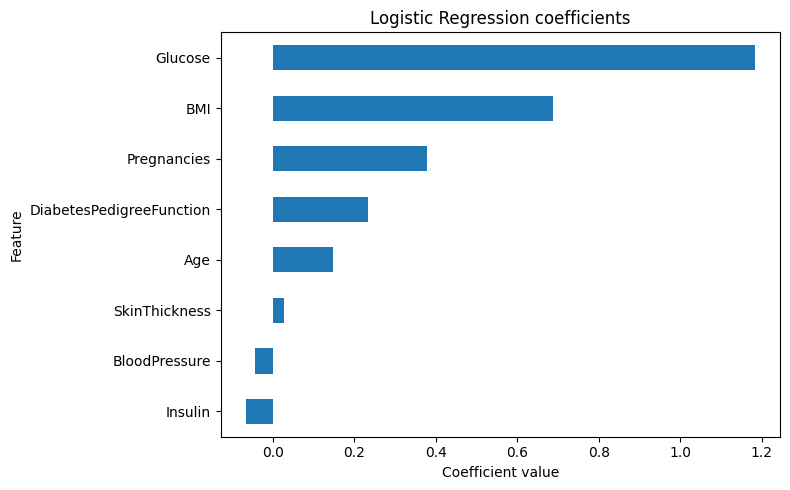

In [7]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

coefficients.sort_values().plot.barh(figsize=(8, 5))

plt.title("Logistic Regression coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("../outputs/figures/logistic_coefficients.png", dpi=300)

plt.show()

## Permutation Importance - regresja logistyczna

In [8]:
from sklearn.inspection import permutation_importance
import pandas as pd

result_logistic = permutation_importance(
    pipeline_logistic,
    X_test_clean,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

importance_logistic_df = pd.DataFrame({
    "Feature": X_test_clean.columns,
    "Importance mean": result_logistic.importances_mean,
    "Importance std": result_logistic.importances_std
}).sort_values("Importance mean", ascending=False)

importance_logistic_df

,Feature,Importance mean,Importance std
1,Glucose,0.159907,0.032571
5,BMI,0.030907,0.018049
0,Pregnancies,0.026111,0.010066
6,DiabetesPedigreeFunction,0.008611,0.003394
7,Age,0.002315,0.001927
4,Insulin,0.001796,0.002329
2,BloodPressure,0.001278,0.000660
3,SkinThickness,0.000056,0.000881


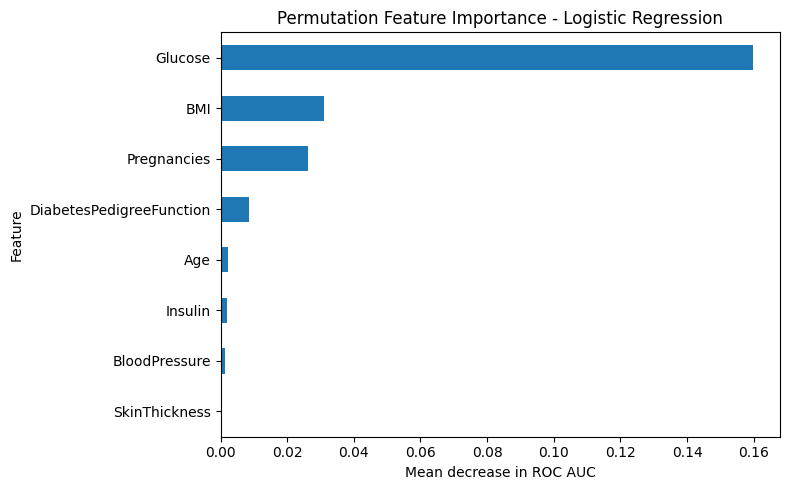

In [9]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

importance_logistic_df.sort_values("Importance mean").plot.barh(
    x="Feature",
    y="Importance mean",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Mean decrease in ROC AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - Logistic Regression")
plt.tight_layout()

plt.savefig("../outputs/figures/permutation_importance_logistic.png", dpi=300)

plt.show()

Wyniki Permutation Importance pokazują, że najważniejszą cechą dla modelu Logistic Regression jest `Glucose`. Jej losowe przemieszanie powoduje największy spadek wartości ROC AUC, co oznacza, że model silnie wykorzystuje tę zmienną podczas predykcji.

Kolejne ważne cechy to `BMI` oraz `Pregnancies`, jednak ich wpływ jest wyraźnie mniejszy niż wpływ poziomu glukozy. Cechy takie jak `SkinThickness`, `BloodPressure` oraz `Insulin` mają bardzo niskie wartości ważności, co oznacza, że ich zaburzenie prawie nie pogarsza jakości modelu.

Wyniki są zgodne z wcześniejszą analizą współczynników regresji logistycznej, gdzie `Glucose` również miała największy dodatni wpływ na przewidywanie klasy 1.

## Random Forest

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

pipeline_rf.fit(X_train_clean, y_train)

print("Random Forest trained.")

Random Forest trained.


## 3. Permutation Feature Importance dla Random Forest

Random Forest jest modelem złożonym, dlatego trudniej bezpośrednio odczytać sposób podejmowania decyzji. Z tego powodu zastosowano Permutation Importance, aby sprawdzić, które cechy najbardziej wpływają na jakość predykcji tego modelu.

In [11]:
from sklearn.inspection import permutation_importance
import pandas as pd

result_rf = permutation_importance(
    pipeline_rf,
    X_test_clean,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

importance_rf_df = pd.DataFrame({
    "Feature": X_test_clean.columns,
    "Importance mean": result_rf.importances_mean,
    "Importance std": result_rf.importances_std
}).sort_values("Importance mean", ascending=False)

importance_rf_df

,Feature,Importance mean,Importance std
1,Glucose,0.085898,0.023383
5,BMI,0.046361,0.013770
7,Age,0.021222,0.008970
6,DiabetesPedigreeFunction,0.010120,0.006778
0,Pregnancies,0.008991,0.011497
4,Insulin,0.005713,0.006941
2,BloodPressure,0.001269,0.006439
3,SkinThickness,0.001009,0.006208


Wyniki Permutation Importance dla modelu Random Forest pokazują, że najważniejszą cechą pozostaje `Glucose`. Jej przemieszanie powoduje największy spadek wartości ROC AUC, co oznacza, że model silnie opiera się na poziomie glukozy podczas przewidywania cukrzycy.

Drugą najważniejszą cechą jest `BMI`, a następnie `Age`, `DiabetesPedigreeFunction` oraz `Pregnancies`. W porównaniu z regresją logistyczną Random Forest przypisuje większe znaczenie wiekowi. Może to wynikać z tego, że model drzewiasty potrafi uchwycić bardziej złożone zależności między cechami.

Cechy takie jak `BloodPressure` i `SkinThickness` mają bardzo niską ważność, co oznacza, że ich przemieszanie prawie nie pogarsza jakości predykcji modelu.

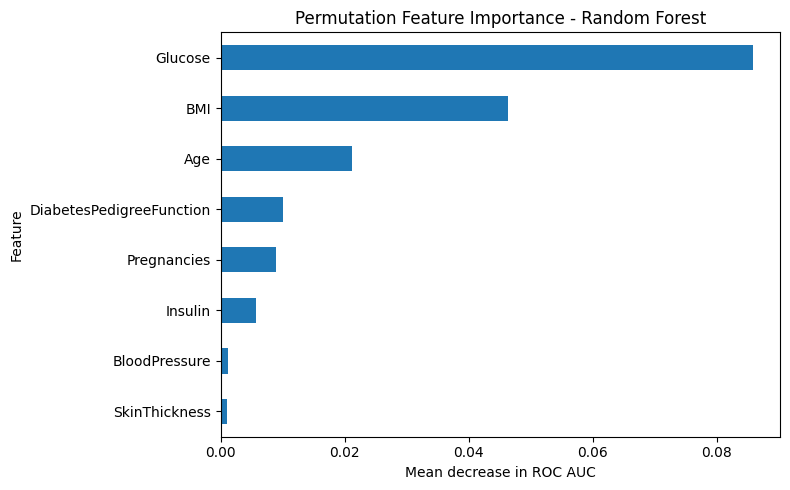

In [12]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

importance_rf_df.sort_values("Importance mean").plot.barh(
    x="Feature",
    y="Importance mean",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Mean decrease in ROC AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - Random Forest")
plt.tight_layout()

plt.savefig("../outputs/figures/permutation_importance_random_forest.png", dpi=300)

plt.show()

## SHAP dla modelu Random Forest

In [13]:
!pip install shap


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\AS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
rf_model = pipeline_rf.named_steps["model"]
imputer = pipeline_rf.named_steps["imputer"]

In [16]:
X_train_rf = pd.DataFrame(
    imputer.transform(X_train_clean),
    columns=X_train_clean.columns,
    index=X_train_clean.index
)

X_test_rf = pd.DataFrame(
    imputer.transform(X_test_clean),
    columns=X_test_clean.columns,
    index=X_test_clean.index
)

## SHAP summary plot

In [17]:
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_rf)

In [18]:
type(shap_values_rf), np.array(shap_values_rf).shape

(numpy.ndarray, (154, 8, 2))

154 = liczba obserwacji w X_test
8 = liczba cech
2 = dwie klasy

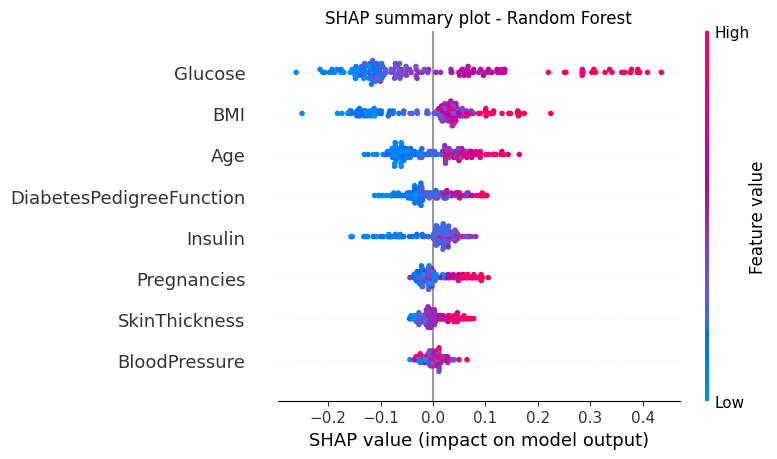

In [19]:
shap.summary_plot(
    shap_values_rf[:, :, 1], # with diabeties
    X_test_rf,
    show=False
)

plt.title("SHAP summary plot - Random Forest")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_summary_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

Wykres SHAP summary plot pokazuje globalny wpływ cech na predykcje modelu Random Forest. Najważniejszą cechą jest `Glucose`, co oznacza, że poziom glukozy miał największy wpływ na decyzje modelu. Wysokie wartości glukozy przesuwają predykcję w stronę klasy 1, czyli cukrzycy, natomiast niższe wartości zmniejszają przewidywane ryzyko.

Istotne znaczenie mają również `BMI`, `Age` oraz `DiabetesPedigreeFunction`. Wyniki są zgodne z wcześniejszą analizą Permutation Importance, ponieważ również tam `Glucose` i `BMI` należały do najważniejszych cech.

Cechy znajdujące się niżej, takie jak `SkinThickness` i `BloodPressure`, mają mniejszy wpływ na predykcje modelu.

## SHAP bar plot

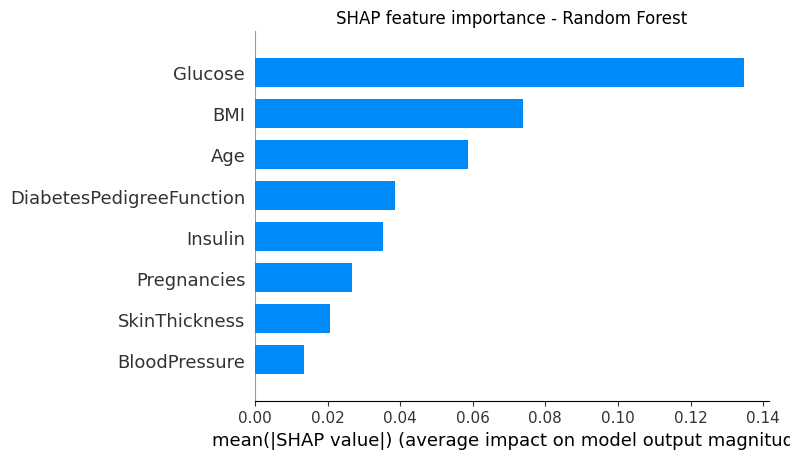

In [20]:
shap.summary_plot(
    shap_values_rf[:, :, 1],
    X_test_rf,
    plot_type="bar",
    show=False
)

plt.title("SHAP feature importance - Random Forest")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_bar_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

Wykres słupkowy SHAP pokazuje ranking cech według ich średniego wpływu na predykcje modelu Random Forest. Najważniejszą cechą jest `Glucose`, co potwierdza wcześniejsze wyniki uzyskane za pomocą Permutation Importance. Wysoko znajdują się również `BMI`, `Age` oraz `DiabetesPedigreeFunction`, co oznacza, że model często wykorzystuje te zmienne przy przewidywaniu klasy 1, czyli cukrzycy.

Wyniki SHAP są spójne z wcześniejszymi analizami — zarówno regresja logistyczna, jak i Random Forest wskazują, że poziom glukozy jest najważniejszą zmienną w tym problemie.

## SHAP waterfall

In [21]:
i = 0

sample_df = X_test_rf.iloc[[i]]

prediction = rf_model.predict(sample_df)[0]
prediction_proba = rf_model.predict_proba(sample_df)[0, 1] # pierwsza osoba, prawdopodobieństwo klasy 1

print("Predicted class:", prediction)
print("Predicted probability of class 1:", prediction_proba)

Predicted class: 1
Predicted probability of class 1: 0.685


c:\Users\AS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\AS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


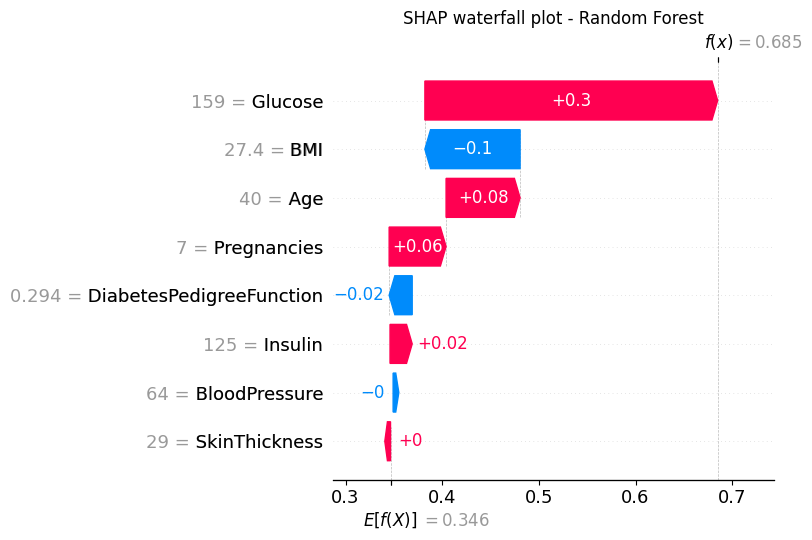

In [22]:
sample = X_test_rf.iloc[i]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_rf[i, :, 1],
        base_values=explainer_rf.expected_value[1],
        data=sample,
        feature_names=X_test_rf.columns
    ),
    show=False
)

plt.title("SHAP waterfall plot - Random Forest")
plt.tight_layout()

plt.savefig("../outputs/figures/shap_waterfall_random_forest.png", dpi=300, bbox_inches="tight")

plt.show()

Wykres waterfall przedstawia lokalne wyjaśnienie jednej predykcji modelu Random Forest. Dla analizowanej obserwacji model przewidział klasę 1, czyli cukrzycę, z prawdopodobieństwem około 68,5%.

Najsilniej w stronę klasy 1 przesunęła predykcję cecha `Glucose` o wartości 159. Dodatni wpływ miały również `Age`, `Pregnancies` oraz `Insulin`. Z kolei `BMI` oraz `DiabetesPedigreeFunction` zmniejszały przewidywane prawdopodobieństwo cukrzycy.

Interpretacja lokalna jest zgodna z wcześniejszymi wynikami globalnymi, ponieważ również tutaj poziom glukozy okazał się najważniejszą cechą wpływającą na decyzję modelu.

## 5. PDP / ICE dla modelu Random Forest

PDP oraz ICE pozwalają sprawdzić, jak zmiana wartości wybranej cechy wpływa na predykcję modelu. PDP pokazuje średni wpływ cechy na wynik modelu, natomiast ICE pokazuje ten wpływ osobno dla pojedynczych obserwacji.

W tej części przeanalizowano cechę `Glucose`, ponieważ wcześniejsze metody XAI wskazały ją jako najważniejszą zmienną w modelu.

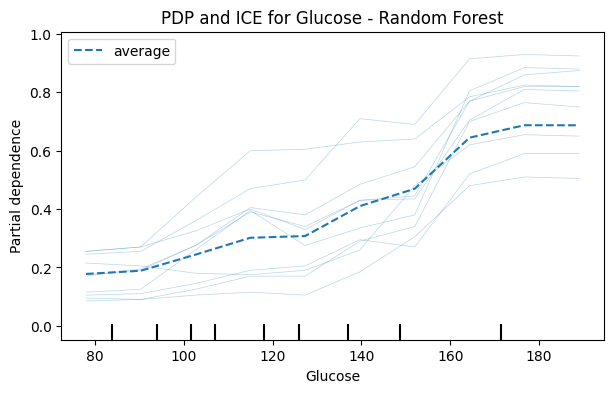

In [29]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import os

os.makedirs("../outputs/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))

PartialDependenceDisplay.from_estimator(
    pipeline_rf,
    X_test_clean,
    features=["Glucose"],
    kind="both",
    response_method="predict_proba",
    target=1,
    subsample=10,
    random_state=42,
    grid_resolution=10,
    ax=ax,

)

plt.title("PDP and ICE for Glucose - Random Forest")

plt.savefig("../outputs/figures/pdp_ice_glucose_random_forest.png", dpi=300)

plt.show()

Wykres PDP/ICE dla cechy `Glucose` pokazuje, że wraz ze wzrostem poziomu glukozy rośnie przewidywane prawdopodobieństwo klasy 1, czyli cukrzycy. Linia średnia PDP wskazuje wyraźny trend rosnący, co jest zgodne z wcześniejszymi wynikami XAI, gdzie `Glucose` była najważniejszą cechą.

Linie ICE pokazują wpływ tej cechy dla pojedynczych obserwacji. Ich rozrzut oznacza, że wpływ glukozy nie jest identyczny dla wszystkich przypadków i może zależeć od pozostałych cech. Jest to typowe dla modeli drzewiastych, takich jak Random Forest, które mogą wykorzystywać nieliniowe zależności i progi decyzyjne.

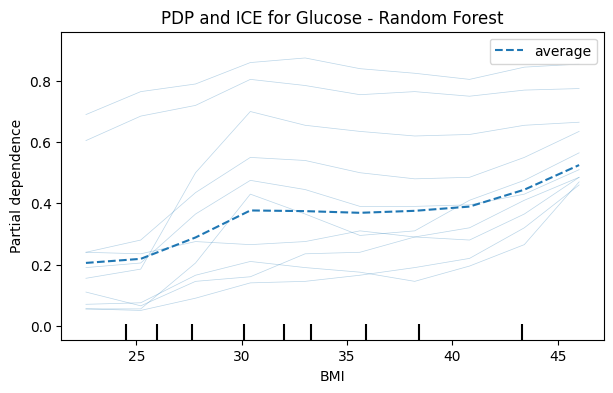

In [30]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import os

os.makedirs("../outputs/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))

PartialDependenceDisplay.from_estimator(
    pipeline_rf,
    X_test_clean,
    features=["BMI"],
    kind="both",
    response_method="predict_proba",
    target=1,
    subsample=10,
    random_state=42,
    grid_resolution=10,
    ax=ax,

)

plt.title("PDP and ICE for Glucose - Random Forest")

plt.savefig("../outputs/figures/pdp_ice_glucose_random_forest.png", dpi=300)

plt.show()

Wykres PDP/ICE dla cechy `BMI` pokazuje, że wraz ze wzrostem BMI przewidywane prawdopodobieństwo klasy 1, czyli cukrzycy, ogólnie rośnie. Wpływ tej cechy nie jest jednak tak silny i jednoznaczny jak w przypadku `Glucose`.

Linie ICE pokazują, że efekt BMI różni się między obserwacjami. Oznacza to, że wpływ BMI na predykcję może zależeć od innych cech pacjentki, takich jak poziom glukozy, wiek czy liczba ciąż. Jest to zgodne z charakterem modelu Random Forest, który może wykorzystywać zależności nieliniowe i interakcje między cechami.

Analiza XAI pokazała, że najważniejszą cechą w przewidywaniu cukrzycy jest `Glucose`. Wynik ten pojawił się konsekwentnie w kilku metodach: we współczynnikach regresji logistycznej, Permutation Importance, SHAP oraz PDP/ICE. Oznacza to, że modele w dużym stopniu opierają swoje decyzje na poziomie glukozy, co jest zgodne z intuicją dotyczącą problemu cukrzycy.

Drugą ważną cechą jest `BMI`. Wpływ BMI był widoczny zarówno w metodzie SHAP, jak i na wykresie PDP/ICE. Wraz ze wzrostem BMI model Random Forest ogólnie przewidywał wyższe prawdopodobieństwo klasy 1, czyli cukrzycy, choć wpływ tej cechy był mniej jednoznaczny niż w przypadku glukozy.

Istotne znaczenie miały również `Age`, `Pregnancies` oraz `DiabetesPedigreeFunction`, jednak ich wpływ był słabszy i bardziej zależny od konkretnej metody oraz modelu. Cechy takie jak `BloodPressure` i `SkinThickness` miały niski wpływ na predykcje.

Wyniki różnych metod XAI są ze sobą spójne: najważniejsze cechy wskazywane przez modele to przede wszystkim `Glucose` i `BMI`. Dzięki temu można uznać, że modele opierają się na sensownych zmiennych, a ich decyzje są częściowo zgodne z wiedzą intuicyjną o cukrzycy.

Jednocześnie modele nie osiągnęły idealnej skuteczności, dlatego nie powinny być traktowane jako narzędzie diagnostyczne. Projekt ma charakter edukacyjny i pokazuje, jak za pomocą metod XAI można analizować działanie modeli klasyfikacyjnych oraz sprawdzać, które cechy wpływają na ich decyzje.